# Retail Supply Chain Analytics

## Exploratory Data Analysis (EDA)

### Objective: The objective of this notebook is to understand the structure, quality and business context of the datasets before designing the ETL pipeline.

The analysis performed in this notebook includes:

- Importing required libraries
- Loading datasets
- Exploring dataset structure
- Assessing data quality
- Converting data types
- Understanding business entities
- Identifying relationships between datasets

In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configure pandas display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Load Datasets

Load the three raw datasets into Pandas DataFrames for exploration.

In [2]:
# =====================================================
# LOAD DATASETS
# =====================================================

sales = pd.read_csv("../data/raw/sales.csv")
features = pd.read_csv("../data/raw/features.csv")
stores = pd.read_csv("../data/raw/stores.csv")

## 2. Dataset Preview

Display the first five rows of each dataset to understand their overall structure.

In [3]:
# =====================================================
# DATASET PREVIEW
# =====================================================

print("=" * 70)
print("SALES DATASET")
print("=" * 70)
display(sales.head())

print("=" * 70)
print("FEATURES DATASET")
print("=" * 70)
display(features.head())

print("=" * 70)
print("STORES DATASET")
print("=" * 70)
display(stores.head())

SALES DATASET


,store_id,department,date,weekly_sales,is_holiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1
3,1,4,2022-01-01,88445.24,1
4,1,5,2022-01-01,65159.85,1


FEATURES DATASET


,store_id,date,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday,holiday_name,season
0,1,2022-01-01,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2022-01-08,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,0,NaN,Winter
2,1,2022-01-15,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,0,NaN,Winter
3,1,2022-01-22,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,0,NaN,Winter
4,1,2022-01-29,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,0,NaN,Winter


STORES DATASET


,store_id,store_type,store_size,region
0,1,A,213810,North
1,2,C,31639,East
2,3,B,102098,South
3,4,B,88289,North
4,5,A,218696,North


## 3. Dataset Dimensions

Determine the number of rows and columns in each dataset.

In [4]:
# =====================================================
# DATASET DIMENSIONS
# =====================================================

print(f"Sales Dataset Shape    : {sales.shape}")
print(f"Features Dataset Shape : {features.shape}")
print(f"Stores Dataset Shape   : {stores.shape}")

Sales Dataset Shape    : (156000, 5)
Features Dataset Shape : (7800, 14)
Stores Dataset Shape   : (50, 4)


## 4. Dataset Columns

Inspect the available columns in each dataset.

In [5]:
# =====================================================
# COLUMN NAMES
# =====================================================

print("Sales Columns")
print(sales.columns.tolist())

print("\nFeatures Columns")
print(features.columns.tolist())

print("\nStores Columns")
print(stores.columns.tolist())

Sales Columns
['store_id', 'department', 'date', 'weekly_sales', 'is_holiday']

Features Columns
['store_id', 'date', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday', 'holiday_name', 'season']

Stores Columns
['store_id', 'store_type', 'store_size', 'region']


## 5. Data Type Inspection

Inspect the data types and identify columns that may require conversion before analysis.

In [6]:
# =====================================================
# DATA TYPES
# =====================================================

print("=" * 70)
print("SALES DATASET")
print("=" * 70)
sales.info()

print("\n" + "=" * 70)
print("FEATURES DATASET")
print("=" * 70)
features.info()

print("\n" + "=" * 70)
print("STORES DATASET")
print("=" * 70)
stores.info()

SALES DATASET
<class 'pandas.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store_id      156000 non-null  int64  
 1   department    156000 non-null  int64  
 2   date          156000 non-null  str    
 3   weekly_sales  156000 non-null  float64
 4   is_holiday    156000 non-null  int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 6.0 MB

FEATURES DATASET
<class 'pandas.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store_id      7800 non-null   int64  
 1   date          7800 non-null   str    
 2   temperature   7800 non-null   float64
 3   fuel_price    7800 non-null   float64
 4   markdown_1    7800 non-null   float64
 5   markdown_2    7800 non-null   float64
 6   markdown_3    7800 non-null   float64
 7   markdown_4    7

## 6. Missing Value Analysis

Identify missing values to assess data quality and determine whether cleaning is required.

In [7]:
# =====================================================
# MISSING VALUE ANALYSIS
# =====================================================

print("Sales Dataset")
display(sales.isnull().sum())

print("Features Dataset")
display(features.isnull().sum())

print("Stores Dataset")
display(stores.isnull().sum())

Sales Dataset


store_id        0
department      0
date            0
weekly_sales    0
is_holiday      0
dtype: int64

Features Dataset


store_id           0
date               0
temperature        0
fuel_price         0
markdown_1         0
markdown_2         0
markdown_3         0
markdown_4         0
markdown_5         0
cpi                0
unemployment       0
is_holiday         0
holiday_name    6900
season             0
dtype: int64

Stores Dataset


store_id      0
store_type    0
store_size    0
region        0
dtype: int64

## 7. Duplicate Record Analysis

Check for duplicate records before performing any aggregations or modelling.

In [8]:
# =====================================================
# DUPLICATE RECORD ANALYSIS
# =====================================================

print(f"Sales Dataset Duplicates    : {sales.duplicated().sum()}")
print(f"Features Dataset Duplicates : {features.duplicated().sum()}")
print(f"Stores Dataset Duplicates   : {stores.duplicated().sum()}")

Sales Dataset Duplicates    : 0
Features Dataset Duplicates : 0
Stores Dataset Duplicates   : 0


## 8. Summary Statistics

Generate descriptive statistics for both numerical and categorical variables.

In [9]:
# =====================================================
# SUMMARY STATISTICS
# =====================================================

print("Sales Dataset")
display(sales.describe())

print("Features Dataset")
display(features.describe())

print("Stores Dataset")
display(stores.describe())

print("Sales Dataset (Categorical)")
display(sales.describe(include="object"))

print("Features Dataset (Categorical)")
display(features.describe(include="object"))

print("Stores Dataset (Categorical)")
display(stores.describe(include="object"))

Sales Dataset


,store_id,department,weekly_sales,is_holiday
count,156000.000000,156000.0000,156000.000000,156000.000000
mean,25.500000,10.5000,56503.488802,0.115385
std,14.430916,5.7663,46717.490663,0.319487
min,1.000000,1.0000,819.660000,0.000000
25%,13.000000,5.7500,21255.962500,0.000000
50%,25.500000,10.5000,43394.870000,0.000000
75%,38.000000,15.2500,79604.107500,0.000000
max,50.000000,20.0000,505958.730000,1.000000


Features Dataset


,store_id,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday
count,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000
mean,25.500000,59.875755,3.986344,2831.840176,1708.091033,2295.922200,1982.042679,2561.790629,240.469559,6.485572,0.115385
std,14.431795,23.116172,0.864077,1977.953750,1187.693694,1579.374985,1351.528967,1769.798978,34.602955,2.015121,0.319506
min,1.000000,20.020000,2.500000,0.180000,0.200000,1.010000,1.130000,0.140000,180.000000,3.000000,0.000000
25%,13.000000,39.942500,3.240000,1308.727500,787.155000,1095.917500,969.917500,1198.375000,211.027500,4.720000,0.000000
50%,25.500000,60.065000,3.970000,2652.495000,1612.570000,2174.595000,1862.980000,2417.900000,240.945000,6.490000,0.000000
75%,38.000000,79.910000,4.750000,4027.545000,2423.002500,3212.695000,2790.137500,3600.245000,270.445000,8.220000,0.000000
max,50.000000,99.970000,5.500000,10977.070000,6599.720000,8798.150000,7692.880000,9891.190000,299.990000,10.000000,1.000000


Stores Dataset


...

C:\Users\Sharad Vidhate\AppData\Local\Temp\ipykernel_7360\2794033811.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(features.describe(include="object"))


,date,holiday_name,season
count,7800,900,7800
unique,156,5,4
top,2022-01-01,Christmas,Summer
freq,50,250,2000


Stores Dataset (Categorical)


C:\Users\Sharad Vidhate\AppData\Local\Temp\ipykernel_7360\2794033811.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(stores.describe(include="object"))


,store_type,region
count,50,50
unique,3,4
top,A,East
freq,26,16


## 9. Categorical Variable Exploration

Determine the number of unique values in categorical columns.

In [10]:
# =====================================================
# UNIQUE VALUES IN CATEGORICAL COLUMNS
# =====================================================

datasets = {
    "Sales": sales,
    "Features": features,
    "Stores": stores
}

for dataset_name, dataframe in datasets.items():

    print("=" * 70)
    print(dataset_name.upper())
    print("=" * 70)

    categorical_columns = dataframe.select_dtypes(include="object").columns

    if len(categorical_columns) == 0:
        print("No categorical columns found.\n")
        continue

    for column in categorical_columns:
        print(f"{column}: {dataframe[column].nunique()} unique values")

SALES
date: 156 unique values
FEATURES
date: 156 unique values
holiday_name: 5 unique values
season: 4 unique values
STORES
store_type: 3 unique values
region: 4 unique values


C:\Users\Sharad Vidhate\AppData\Local\Temp\ipykernel_7360\97489612.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = dataframe.select_dtypes(include="object").columns
C:\Users\Sharad Vidhate\AppData\Local\Temp\ipykernel_7360\97489612.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pan

## 10. Date Conversion

Convert the date columns from string format to datetime for time-series analysis.

In [11]:
# =====================================================
# DATE CONVERSION
# =====================================================

sales["date"] = pd.to_datetime(sales["date"])
features["date"] = pd.to_datetime(features["date"])

print("Updated Sales Dataset")

sales.info()

print("\nUpdated Features Dataset")

features.info()

Updated Sales Dataset
<class 'pandas.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store_id      156000 non-null  int64         
 1   department    156000 non-null  int64         
 2   date          156000 non-null  datetime64[us]
 3   weekly_sales  156000 non-null  float64       
 4   is_holiday    156000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 6.0 MB

Updated Features Dataset
<class 'pandas.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store_id      7800 non-null   int64         
 1   date          7800 non-null   datetime64[us]
 2   temperature   7800 non-null   float64       
 3   fuel_price    7800 non-null   float64       
 4   markdown_1    7800 non-nul

## 11. Temporal Coverage

Determine the time period covered by the datasets.

In [12]:
# =====================================================
# DATE RANGE
# =====================================================

print(f"Sales Dataset Start Date    : {sales['date'].min()}")
print(f"Sales Dataset End Date      : {sales['date'].max()}")

print()

print(f"Features Dataset Start Date : {features['date'].min()}")
print(f"Features Dataset End Date   : {features['date'].max()}")

Sales Dataset Start Date    : 2022-01-01 00:00:00
Sales Dataset End Date      : 2024-12-21 00:00:00

Features Dataset Start Date : 2022-01-01 00:00:00
Features Dataset End Date   : 2024-12-21 00:00:00


## 12. Initial Business Understanding

Explore key business entities before performing deeper analysis.

In [13]:
# =====================================================
# INITIAL BUSINESS UNDERSTANDING
# =====================================================

print(f"Number of Stores                 : {sales['store_id'].nunique()}")
print(f"Number of Departments            : {sales['department'].nunique()}")
print(f"Number of Feature Store Records  : {features['store_id'].nunique()}")

print("\nStore Types")
display(stores["store_type"].value_counts())

print("\nRegional Distribution")
display(stores["region"].value_counts())

Number of Stores                 : 50
Number of Departments            : 20
Number of Feature Store Records  : 50

Store Types


store_type
A    26
B    16
C     8
Name: count, dtype: int64


Regional Distribution


region
East     16
North    13
South    12
West      9
Name: count, dtype: int64

## 13. Initial Findings

### Key Findings

- The Sales dataset contains weekly sales transactions for each department within each store.
- The Features dataset contains external variables such as temperature, fuel price, CPI, unemployment and promotional markdowns that may influence sales.
- The Stores dataset contains descriptive information about each retail store.

### Data Quality Assessment

- No duplicate records were identified in any dataset.
- No missing values were found in the Sales or Stores datasets.
- The only missing values occur in `holiday_name`, which likely indicates weeks that are not associated with a holiday rather than missing data.
- Date columns were converted from string to `datetime` format to enable time-series analysis.

### Next Steps

The next phase of the project will focus on:

1. Sales trend analysis
2. Store performance analysis
3. Department performance analysis
4. Holiday impact on sales
5. Correlation analysis
6. Feature engineering
7. ETL pipeline design

## 14. Data Integration

To perform comprehensive business analysis, the three datasets are merged into a single analytical dataset.

The merge is performed as follows:

- Sales ↔ Features using `store_id` and `date`
- Resulting_dataset ↔ Stores using `store_id`

This combined dataset will be used for exploratory analysis and visualisations.

In [14]:
# =====================================================
# DATA INTEGRATION
# =====================================================

# Merge Sales and Features datasets
analysis_df = pd.merge(
    sales,
    features,
    on=["store_id", "date"],
    how="left"
)

# Merge the resulting dataset with Stores
analysis_df = pd.merge(
    analysis_df,
    stores,
    on="store_id",
    how="left"
)

print(f"Combined Dataset Shape: {analysis_df.shape}")

analysis_df.head()

Combined Dataset Shape: (156000, 20)


,store_id,department,date,weekly_sales,is_holiday_x,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday_y,holiday_name,season,store_type,store_size,region
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
1,1,2,2022-01-01,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
2,1,3,2022-01-01,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
3,1,4,2022-01-01,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North
4,1,5,2022-01-01,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter,A,213810,North


## 15. Merge Validation

After merging, validate that:

- The number of rows has not changed unexpectedly.
- Store information has been merged correctly.
- No new missing values have been introduced due to incorrect join keys.

In [15]:
# =====================================================
# MERGE VALIDATION
# =====================================================

print("=" * 70)
print("MERGED DATASET INFORMATION")
print("=" * 70)

print(f"Shape of merged dataset: {analysis_df.shape}")

print("\nMissing values after merge:")
display(analysis_df.isnull().sum())

MERGED DATASET INFORMATION
Shape of merged dataset: (156000, 20)

Missing values after merge:


store_id             0
department           0
date                 0
weekly_sales         0
is_holiday_x         0
temperature          0
fuel_price           0
markdown_1           0
markdown_2           0
markdown_3           0
markdown_4           0
markdown_5           0
cpi                  0
unemployment         0
is_holiday_y         0
holiday_name    138000
season               0
store_type           0
store_size           0
region               0
dtype: int64

## 16. Holiday Column Validation

The merged dataset contains two holiday indicator columns because both the Sales and Features datasets included an `is_holiday` field.

Before removing one of them, verify that both columns contain identical values.

In [16]:
# =====================================================
# HOLIDAY COLUMN VALIDATION
# =====================================================

# Check whether both holiday indicator columns are identical.
holiday_match = (analysis_df["is_holiday_x"] == analysis_df["is_holiday_y"]).all()

print(f"Are both holiday columns identical? {holiday_match}")

Are both holiday columns identical? True


In [17]:
# =====================================================
# REMOVE DUPLICATE HOLIDAY COLUMN
# =====================================================

analysis_df = analysis_df.drop(columns=["is_holiday_y"])

analysis_df = analysis_df.rename(
    columns={"is_holiday_x": "is_holiday"}
)

analysis_df.head()

,store_id,department,date,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,holiday_name,season,store_type,store_size,region
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
1,1,2,2022-01-01,119107.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
2,1,3,2022-01-01,84369.88,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
3,1,4,2022-01-01,88445.24,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
4,1,5,2022-01-01,65159.85,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North


# Business Exploratory Data Analysis (Business EDA)

## Objective

The objective of this phase is to transform the integrated dataset into actionable business insights.

Rather than simply describing the data, this analysis aims to answer practical business questions related to sales performance, store performance, customer demand, seasonality and external business drivers.

Each analysis includes:

- Business question
- Business rationale
- Data analysis
- Visualisation
- Key findings
- Business implications

## 1. Weekly Sales Trend Analysis

### Business Question

How have total weekly sales changed over time?

### Business Importance

Monitoring sales trends enables the business to:

- Understand overall company performance.
- Detect seasonal demand.
- Identify unusual sales spikes or declines.
- Support demand forecasting.
- Evaluate long-term business growth.

This analysis provides a high-level view of the organisation's sales performance across the entire study period.

In [18]:
# =====================================================
# WEEKLY SALES TREND ANALYSIS
# =====================================================

# Aggregate weekly sales across all stores and departments.
# This creates one record per week, representing total company sales.

weekly_sales = (
    analysis_df
    .groupby("date", as_index=False)["weekly_sales"]
    .sum()
)

print("Weekly Sales Dataset")

display(weekly_sales.head())

Weekly Sales Dataset


,date,weekly_sales
0,2022-01-01,70902987.20
1,2022-01-08,56437421.26
2,2022-01-15,55090458.09
3,2022-01-22,56719185.29
4,2022-01-29,55336034.35


### Visualisation

The following line chart illustrates the overall trend in weekly sales across all stores and departments.

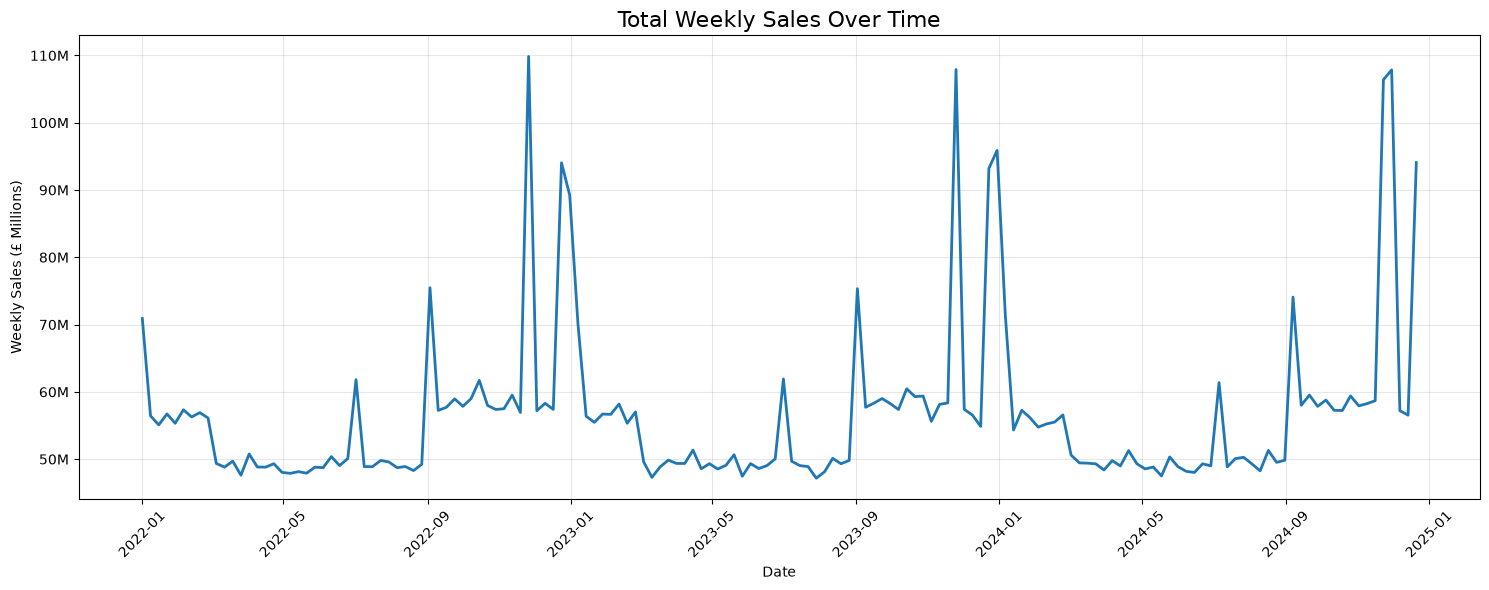

In [19]:
from matplotlib.ticker import FuncFormatter

# =====================================================
# VISUALISE WEEKLY SALES TREND
# =====================================================

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_sales["date"],
    weekly_sales["weekly_sales"],
    linewidth=2
)

# Format the y-axis to display values in millions
formatter = FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Total Weekly Sales Over Time", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Weekly Sales (£ Millions)")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [20]:
# =====================================================
# SALES TREND SUMMARY
# =====================================================

print(f"Total Weeks Analysed : {weekly_sales.shape[0]}")

print(f"Highest Weekly Sales : {weekly_sales['weekly_sales'].max():,.2f}")

print(f"Lowest Weekly Sales  : {weekly_sales['weekly_sales'].min():,.2f}")

print(f"Average Weekly Sales : {weekly_sales['weekly_sales'].mean():,.2f}")

Total Weeks Analysed : 156
Highest Weekly Sales : 109,851,797.54
Lowest Weekly Sales  : 47,170,184.10
Average Weekly Sales : 56,503,488.80


### Key Findings

- Weekly sales remain relatively stable throughout the majority of the observation period, with a baseline ranging between approximately £48 million and £60 million.
- Several recurring sales peaks are observed, particularly towards the end of each calendar year, indicating strong seasonal demand.
- Peak weekly sales reached approximately £109.9 million, almost double the average weekly sales of £56.5 million.
- Sales quickly return to their baseline following each peak, suggesting that these increases are driven by short-term seasonal events rather than sustained business growth.
- Overall, the retail business demonstrates consistent operational performance with predictable seasonal fluctuations.

### Business Implications

The observed seasonality suggests that inventory levels, staffing, warehouse capacity and promotional campaigns should be strategically increased during peak demand periods while maintaining efficient operations during regular trading weeks.

The consistency of baseline sales also provides a strong foundation for demand forecasting and inventory planning.

## 2. Store Performance Analysis

### Business Question

Which stores generate the highest total sales?

### Business Importance

Comparing store performance helps identify high-performing and low-performing locations. These insights can support:

- Inventory allocation
- Staffing decisions
- Expansion planning
- Operational improvements
- Performance benchmarking

Understanding store-level performance enables management to focus resources where they will have the greatest business impact.

In [21]:
# =====================================================
# STORE PERFORMANCE ANALYSIS
# =====================================================

# Calculate total sales for each store across the entire dataset.
store_sales = (
    analysis_df
    .groupby("store_id", as_index=False)["weekly_sales"]
    .sum()
)

# Sort stores from highest to lowest sales.
store_sales = store_sales.sort_values(
    by="weekly_sales",
    ascending=False
)

print("Top 10 Performing Stores")

display(store_sales.head(10))

Top 10 Performing Stores


,store_id,weekly_sales
31,32,3.032230e+08
40,41,3.018119e+08
4,5,3.000639e+08
0,1,2.999050e+08
10,11,2.923540e+08
36,37,2.913743e+08
5,6,2.901179e+08
46,47,2.857667e+08
37,38,2.807494e+08
22,23,2.796390e+08


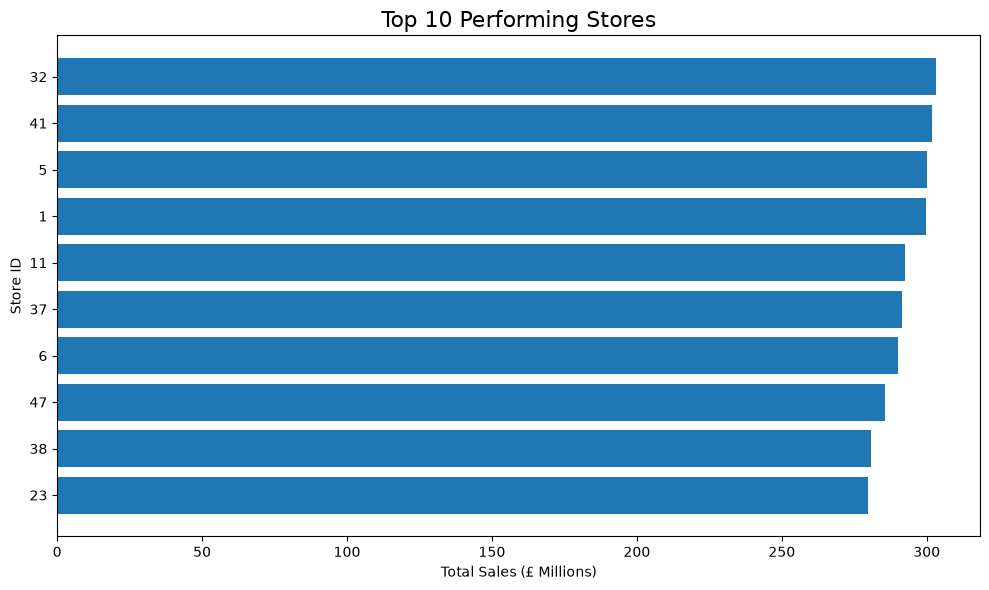

In [22]:
# =====================================================
# TOP 10 PERFORMING STORES
# =====================================================

top10_stores = store_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_stores["store_id"].astype(str),
    top10_stores["weekly_sales"] / 1_000_000
)

plt.gca().invert_yaxis()

plt.title("Top 10 Performing Stores", fontsize=16)

plt.xlabel("Total Sales (£ Millions)")

plt.ylabel("Store ID")

plt.tight_layout()

plt.show()

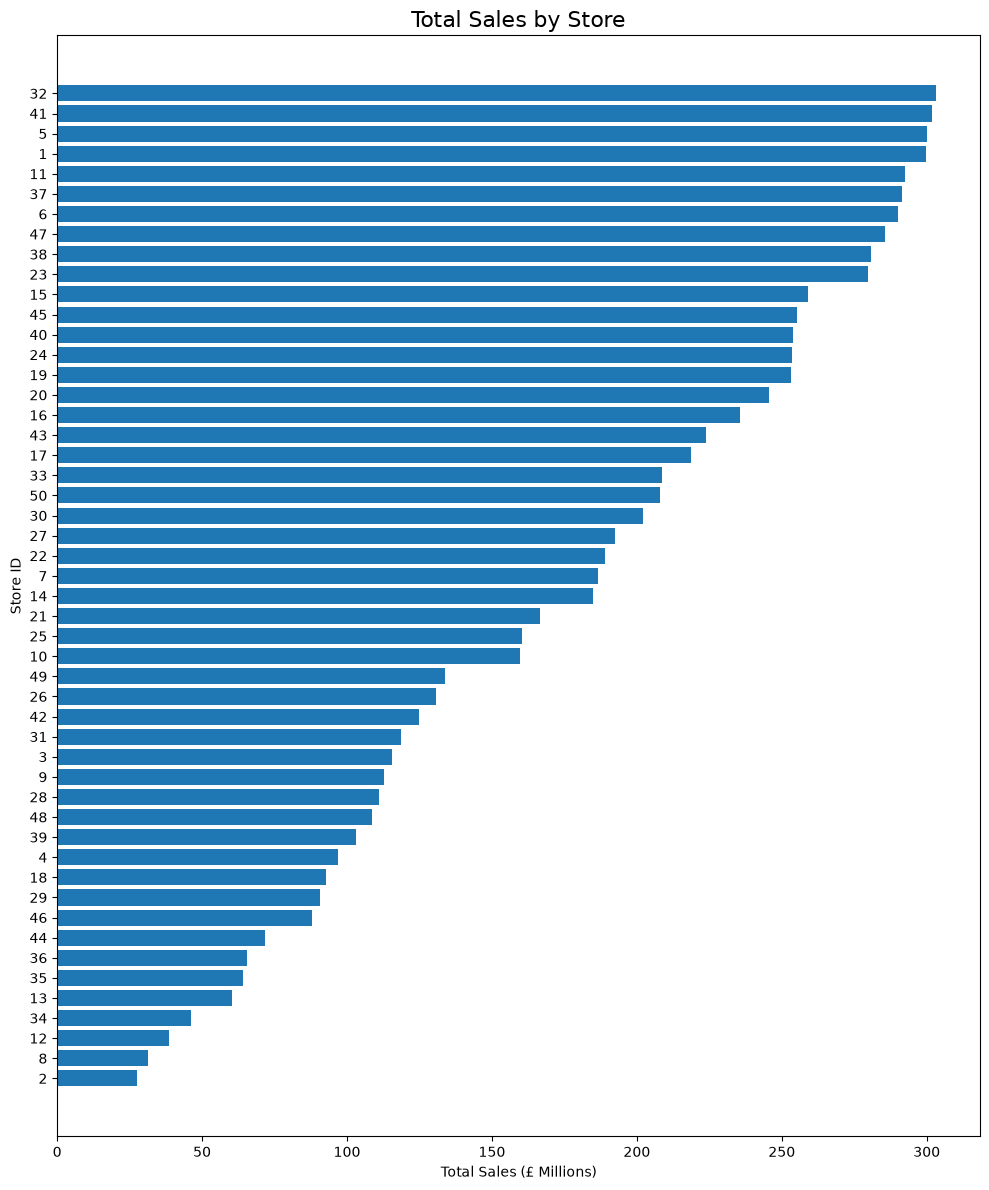

In [23]:
# =====================================================
# VISUALISE STORE PERFORMANCE
# =====================================================

plt.figure(figsize=(10, 12))

plt.barh(
    store_sales["store_id"].astype(str),
    store_sales["weekly_sales"] / 1_000_000
)

plt.title("Total Sales by Store", fontsize=16)

plt.xlabel("Total Sales (£ Millions)")

plt.ylabel("Store ID")

plt.gca().invert_yaxis()  # Highest-performing store at the top

plt.tight_layout()

plt.show()

In [24]:
# =====================================================
# STORE PERFORMANCE SUMMARY
# =====================================================

print(f"Number of Stores : {store_sales.shape[0]}")

print(
    f"Highest Store Sales : £{store_sales['weekly_sales'].max():,.2f}"
)

print(
    f"Lowest Store Sales : £{store_sales['weekly_sales'].min():,.2f}"
)

print(
    f"Average Store Sales : £{store_sales['weekly_sales'].mean():,.2f}"
)

Number of Stores : 50
Highest Store Sales : £303,223,049.45
Lowest Store Sales : £27,377,684.86
Average Store Sales : £176,290,885.06


### Key Findings

- Store performance varies considerably across the retail network.
- The highest-performing store generated approximately £303 million in sales, while the lowest-performing store generated approximately £27 million.
- Several stores consistently outperform the network average, indicating multiple strong-performing locations rather than reliance on a single flagship store.
- A small group of stores contributes significantly less revenue and may require further investigation.
- Differences in store performance are likely influenced by multiple operational and regional factors, which will be explored in later analyses.

### Business Implications

Management should investigate the operational characteristics of high-performing stores to identify best practices that can be adopted across the retail network. Lower-performing stores should be evaluated alongside factors such as store size, location and regional demand before implementing corrective actions.

## 3. Department Performance Analysis

### Business Question

Which departments generate the highest total sales?

### Business Importance

Understanding department performance helps businesses:

- Identify the strongest revenue-generating departments.
- Allocate inventory more effectively.
- Optimise promotional campaigns.
- Improve shelf-space planning.
- Prioritise investment in high-performing product categories.

Department-level analysis enables data-driven merchandising and inventory management decisions.

In [25]:
# =====================================================
# DEPARTMENT PERFORMANCE ANALYSIS
# =====================================================

# Calculate total sales for each department across all stores.
department_sales = (
    analysis_df
    .groupby("department", as_index=False)["weekly_sales"]
    .sum()
)

# Sort departments by total sales.
department_sales = department_sales.sort_values(
    by="weekly_sales",
    ascending=False
)

print("Top 10 Performing Departments")

display(department_sales.head(10))

Top 10 Performing Departments


,department,weekly_sales
19,20,5.923036e+08
18,19,5.725349e+08
17,18,5.601886e+08
16,17,5.398004e+08
15,16,5.296860e+08
14,15,5.089252e+08
13,14,4.917602e+08
12,13,4.749228e+08
11,12,4.671906e+08
10,11,4.541135e+08


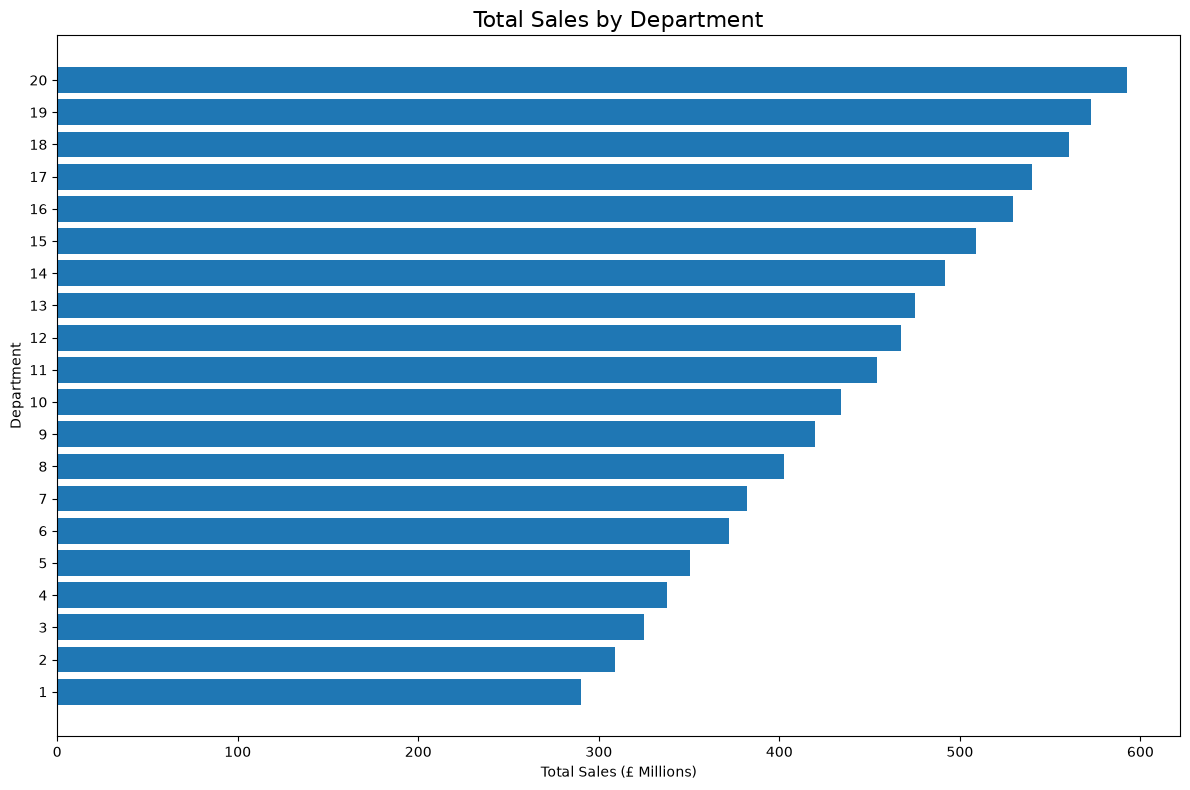

In [26]:
# =====================================================
# ALL DEPARTMENTS BY SALES
# =====================================================

plt.figure(figsize=(12, 8))

plt.barh(
    department_sales["department"].astype(str),
    department_sales["weekly_sales"] / 1_000_000
)

plt.gca().invert_yaxis()

plt.title("Total Sales by Department", fontsize=16)

plt.xlabel("Total Sales (£ Millions)")

plt.ylabel("Department")

plt.tight_layout()

plt.show()

In [27]:
# =====================================================
# DEPARTMENT SUMMARY
# =====================================================

print(f"Number of Departments : {department_sales.shape[0]}")

print(
    f"Highest Department Sales : £{department_sales['weekly_sales'].max():,.2f}"
)

print(
    f"Lowest Department Sales : £{department_sales['weekly_sales'].min():,.2f}"
)

print(
    f"Average Department Sales : £{department_sales['weekly_sales'].mean():,.2f}"
)

Number of Departments : 20
Highest Department Sales : £592,303,555.36
Lowest Department Sales : £290,164,769.98
Average Department Sales : £440,727,212.66


In [28]:
# =====================================================
# DEPARTMENT CONTRIBUTION
# =====================================================

# Calculate the total company sales.
total_sales = department_sales["weekly_sales"].sum()

# Calculate each department's contribution as a percentage.
department_sales["sales_percentage"] = (
    department_sales["weekly_sales"] / total_sales
) * 100

print("Top 10 Department Contributions")

display(
    department_sales[
        ["department", "weekly_sales", "sales_percentage"]
    ].head(10)
)

Top 10 Department Contributions


,department,weekly_sales,sales_percentage
19,20,5.923036e+08,6.719616
18,19,5.725349e+08,6.495344
17,18,5.601886e+08,6.355276
16,17,5.398004e+08,6.123974
15,16,5.296860e+08,6.009227
14,15,5.089252e+08,5.773698
13,14,4.917602e+08,5.578963
12,13,4.749228e+08,5.387945
11,12,4.671906e+08,5.300224
10,11,4.541135e+08,5.151866


### Key Findings

- Department sales are relatively well distributed across the retail business.
- The highest-performing department generated approximately £592 million in total sales, while the lowest-performing department generated approximately £290 million.
- No individual department contributes more than 7% of total company sales.
- Revenue declines gradually across departments, indicating a balanced product portfolio rather than dependence on a small number of categories.
- The analysis suggests consistent customer demand across multiple departments.

### Business Implications

The balanced revenue distribution reduces dependence on individual departments and supports a diversified merchandising strategy. Management should continue investing across product categories while monitoring department-specific trends to optimise inventory allocation and promotional activities.

## 4. Regional Performance Analysis

### Business Question

Which regions generate the highest total sales?

### Business Importance

Regional sales analysis helps organisations understand geographical performance differences and supports strategic decisions such as:

- Inventory distribution
- Warehouse planning
- Regional marketing campaigns
- Store expansion
- Resource allocation

Comparing regional performance enables management to identify high-performing markets and areas requiring additional support.

In [29]:
# =====================================================
# NUMBER OF STORES BY REGION
# =====================================================

stores_per_region = (
    stores
    .groupby("region")
    .size()
    .reset_index(name="number_of_stores")
)

display(stores_per_region)

,region,number_of_stores
0,East,16
1,North,13
2,South,12
3,West,9


In [30]:
# =====================================================
# REGIONAL PERFORMANCE ANALYSIS
# =====================================================

# Calculate total sales for each region.
region_sales = (
    analysis_df
    .groupby("region", as_index=False)["weekly_sales"]
    .sum()
)

# Sort regions from highest to lowest sales.
region_sales = region_sales.sort_values(
    by="weekly_sales",
    ascending=False
)

print("Regional Sales")

display(region_sales)

Regional Sales


,region,weekly_sales
0,East,2.899521e+09
1,North,2.482308e+09
2,South,1.956578e+09
3,West,1.476137e+09


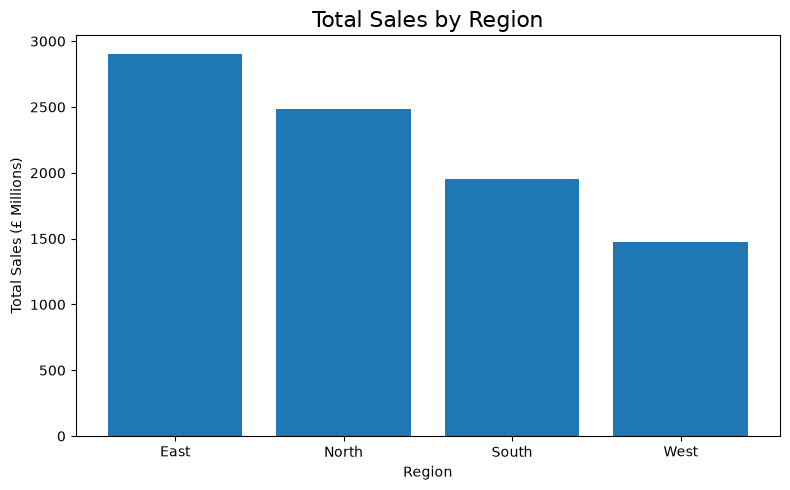

In [31]:
# =====================================================
# VISUALISE REGIONAL SALES
# =====================================================

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales["region"],
    region_sales["weekly_sales"] / 1_000_000
)

plt.title("Total Sales by Region", fontsize=16)

plt.xlabel("Region")

plt.ylabel("Total Sales (£ Millions)")

plt.tight_layout()

plt.show()

In [32]:
# =====================================================
# REGIONAL CONTRIBUTION
# =====================================================

company_sales = region_sales["weekly_sales"].sum()

region_sales["sales_percentage"] = (
    region_sales["weekly_sales"] / company_sales
) * 100

display(region_sales)

,region,weekly_sales,sales_percentage
0,East,2.899521e+09,32.894733
1,North,2.482308e+09,28.161504
2,South,1.956578e+09,22.197160
3,West,1.476137e+09,16.746603


In [33]:
# =====================================================
# REGIONAL SUMMARY
# =====================================================

print(f"Number of Regions : {region_sales.shape[0]}")

print(
    f"Highest Regional Sales : £{region_sales['weekly_sales'].max():,.2f}"
)

print(
    f"Lowest Regional Sales : £{region_sales['weekly_sales'].min():,.2f}"
)

print(
    f"Average Regional Sales : £{region_sales['weekly_sales'].mean():,.2f}"
)

Number of Regions : 4
Highest Regional Sales : £2,899,520,803.01
Lowest Regional Sales : £1,476,136,769.74
Average Regional Sales : £2,203,636,063.28


### Key Findings

- The East region generated the highest revenue, contributing approximately 33% of total company sales.
- The North region contributed approximately 28% of total sales, making it the second strongest market.
- Together, the East and North regions account for over 60% of company revenue.
- The South region generated approximately 22% of sales, while the West region contributed approximately 17%.
- Regional performance is uneven, suggesting differences in market demand, store distribution or operational characteristics.

### Business Implications

Regional performance should be considered when allocating inventory, planning marketing campaigns and evaluating future expansion opportunities. Lower-performing regions should be analysed further to determine whether operational improvements or strategic investments are required.

## 5. Store Type Performance Analysis

### Business Question

How does sales performance differ across store types?

### Business Importance

Different store formats often serve different customer segments and geographic markets. Analysing sales by store type helps management:

- Evaluate the profitability of each store format.
- Support future expansion decisions.
- Allocate inventory appropriately.
- Optimise staffing and operational planning.

Understanding store-type performance helps determine which business model delivers the strongest commercial results.

In [34]:
# =====================================================
# STORE TYPE PERFORMANCE ANALYSIS
# =====================================================

# Calculate total sales for each store type.
store_type_sales = (
    analysis_df
    .groupby("store_type", as_index=False)["weekly_sales"]
    .sum()
)

# Sort store types from highest to lowest sales.
store_type_sales = store_type_sales.sort_values(
    by="weekly_sales",
    ascending=False
)

print("Sales by Store Type")

display(store_type_sales)

Sales by Store Type


,store_type,weekly_sales
0,A,6.495013e+09
1,B,1.914609e+09
2,C,4.049221e+08


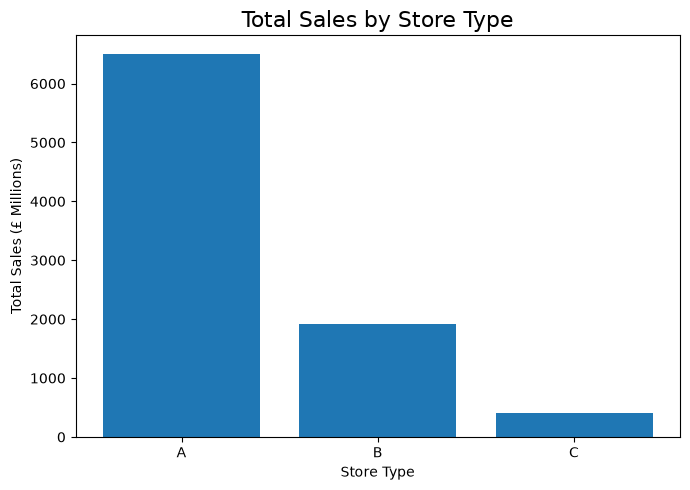

In [35]:
# =====================================================
# VISUALISE STORE TYPE SALES
# =====================================================

plt.figure(figsize=(7, 5))

plt.bar(
    store_type_sales["store_type"],
    store_type_sales["weekly_sales"] / 1_000_000
)

plt.title("Total Sales by Store Type", fontsize=16)

plt.xlabel("Store Type")

plt.ylabel("Total Sales (£ Millions)")

plt.tight_layout()

plt.show()

In [36]:
# =====================================================
# STORE TYPE CONTRIBUTION
# =====================================================

total_sales = store_type_sales["weekly_sales"].sum()

store_type_sales["sales_percentage"] = (
    store_type_sales["weekly_sales"] / total_sales
) * 100

display(store_type_sales)

,store_type,weekly_sales,sales_percentage
0,A,6.495013e+09,73.685179
1,B,1.914609e+09,21.721026
2,C,4.049221e+08,4.593795


In [37]:
# =====================================================
# NUMBER OF STORES BY STORE TYPE
# =====================================================

store_type_count = (
    stores
    .groupby("store_type")
    .size()
    .reset_index(name="number_of_stores")
)

display(store_type_count)

,store_type,number_of_stores
0,A,26
1,B,16
2,C,8


In [38]:
# =====================================================
# AVERAGE SALES PER STORE TYPE
# =====================================================

store_type_summary = store_type_sales.merge(
    store_type_count,
    on="store_type"
)

store_type_summary["average_sales_per_store"] = (
    store_type_summary["weekly_sales"] /
    store_type_summary["number_of_stores"]
)

display(store_type_summary)

,store_type,weekly_sales,sales_percentage,number_of_stores,average_sales_per_store
0,A,6.495013e+09,73.685179,26,2.498082e+08
1,B,1.914609e+09,21.721026,16,1.196631e+08
2,C,4.049221e+08,4.593795,8,5.061526e+07


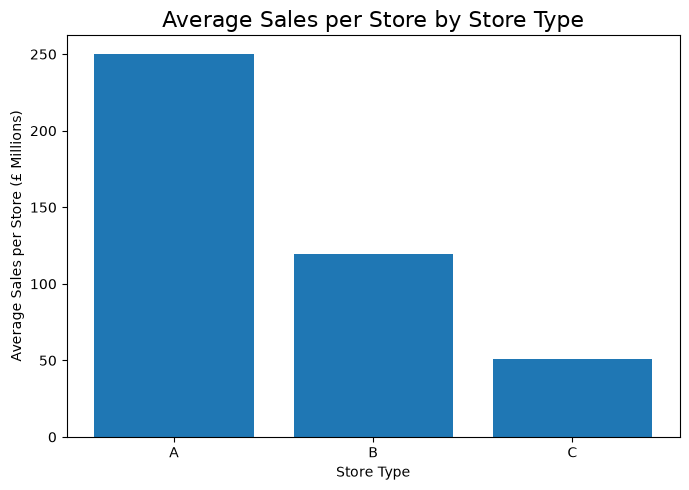

In [39]:
# =====================================================
# AVERAGE SALES PER STORE TYPE
# =====================================================

plt.figure(figsize=(7, 5))

plt.bar(
    store_type_summary["store_type"],
    store_type_summary["average_sales_per_store"] / 1_000_000
)

plt.title("Average Sales per Store by Store Type", fontsize=16)

plt.xlabel("Store Type")

plt.ylabel("Average Sales per Store (£ Millions)")

plt.tight_layout()

plt.show()

### Key Findings

- Type A stores generated approximately £6.50 billion in sales, representing nearly 74% of total company revenue.
- Type B stores contributed approximately 22% of total sales, while Type C stores contributed less than 5%.
- Type A stores also achieved the highest average sales per store, generating approximately £250 million each.
- Average sales per store decrease substantially from Type A to Type B and Type C.
- The results indicate that larger store formats contribute disproportionately to overall company revenue.

### Business Implications

Type A stores represent the company's primary revenue-generating format and appear to be the most commercially productive. Expansion decisions should consider the success of this format while recognising that smaller store types may fulfil strategic objectives beyond revenue generation, such as improving market coverage and customer accessibility.

## 6. Store Size vs Sales Analysis

### Business Question

Does store size influence sales performance?

### Business Importance

Retail organisations invest significant capital when constructing or expanding stores. Understanding the relationship between store size and sales helps management:

- Determine whether larger stores consistently generate higher revenue.
- Evaluate whether expanding existing stores is financially justified.
- Support decisions on future store development.
- Improve long-term capacity and investment planning.

This analysis investigates whether store size is a strong indicator of sales performance.

In [40]:
# =====================================================
# STORE SIZE VS SALES
# =====================================================

# Calculate total sales for each store.
store_sales = (
    analysis_df
    .groupby("store_id", as_index=False)["weekly_sales"]
    .sum()
)

# Merge store metadata (size and type).
store_sales = store_sales.merge(
    stores,
    on="store_id"
)

display(store_sales.head())

,store_id,weekly_sales,store_type,store_size,region
0,1,2.999050e+08,A,213810,North
1,2,2.737768e+07,C,31639,East
2,3,1.155300e+08,B,102098,South
3,4,9.696535e+07,B,88289,North
4,5,3.000639e+08,A,218696,North


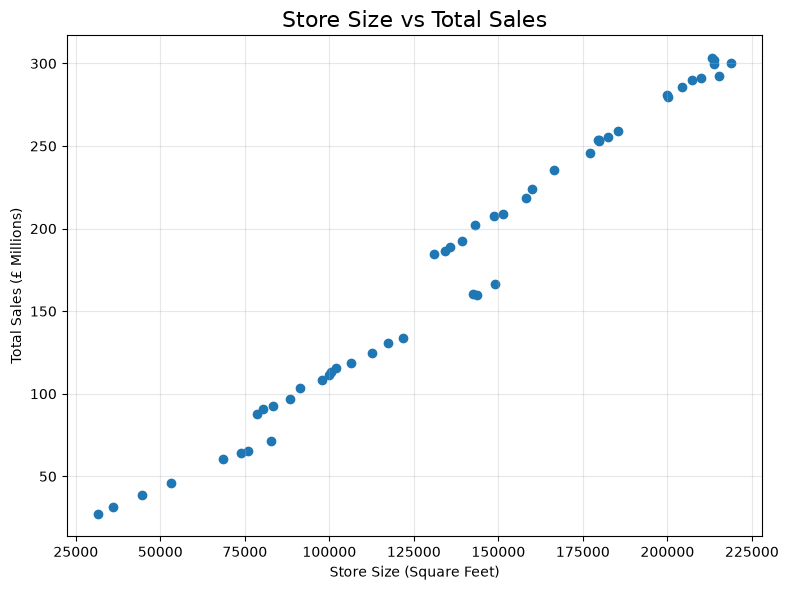

In [41]:
# =====================================================
# SCATTER PLOT
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    store_sales["store_size"],
    store_sales["weekly_sales"] / 1_000_000
)

plt.title("Store Size vs Total Sales", fontsize=16)

plt.xlabel("Store Size (Square Feet)")

plt.ylabel("Total Sales (£ Millions)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [42]:
# =====================================================
# CORRELATION
# =====================================================

correlation = store_sales["store_size"].corr(
    store_sales["weekly_sales"]
)

print(f"Correlation between Store Size and Sales: {correlation:.3f}")

Correlation between Store Size and Sales: 0.991


In [43]:
# =====================================================
# LARGEST STORES
# =====================================================

largest_stores = (
    store_sales
    .sort_values("store_size", ascending=False)
    .head(10)
)

display(largest_stores)

,store_id,weekly_sales,store_type,store_size,region
4,5,3.000639e+08,A,218696,North
10,11,2.923540e+08,A,215181,West
40,41,3.018119e+08,A,213886,South
0,1,2.999050e+08,A,213810,North
31,32,3.032230e+08,A,213320,East
36,37,2.913743e+08,A,209840,South
5,6,2.901179e+08,A,207397,West
46,47,2.857667e+08,A,204341,East
22,23,2.796390e+08,A,200284,North
37,38,2.807494e+08,A,200010,South


In [44]:
# =====================================================
# SMALLEST STORES
# =====================================================

smallest_stores = (
    store_sales
    .sort_values("store_size")
    .head(10)
)

display(smallest_stores)

,store_id,weekly_sales,store_type,store_size,region
1,2,27377684.86,C,31639,East
7,8,31361162.23,C,36140,South
11,12,38613465.75,C,44446,West
33,34,46033475.43,C,53283,South
12,13,60273453.26,C,68618,East
34,35,64256626.86,C,73920,East
35,36,65444402.71,C,75994,North
45,46,87890737.44,B,78675,South
28,29,90800226.84,B,80458,South
43,44,71561803.51,C,82759,East


In [45]:
# =====================================================
# STORE TYPE SUMMARY
# =====================================================

store_type_summary_size = (
    store_sales
    .groupby("store_type", as_index=False)
    .agg(
        average_store_size=("store_size", "mean"),
        average_sales=("weekly_sales", "mean")
    )
)

display(store_type_summary_size)

,store_type,average_store_size,average_sales
0,A,178796.538462,2.498082e+08
1,B,107238.312500,1.196631e+08
2,C,58349.875000,5.061526e+07


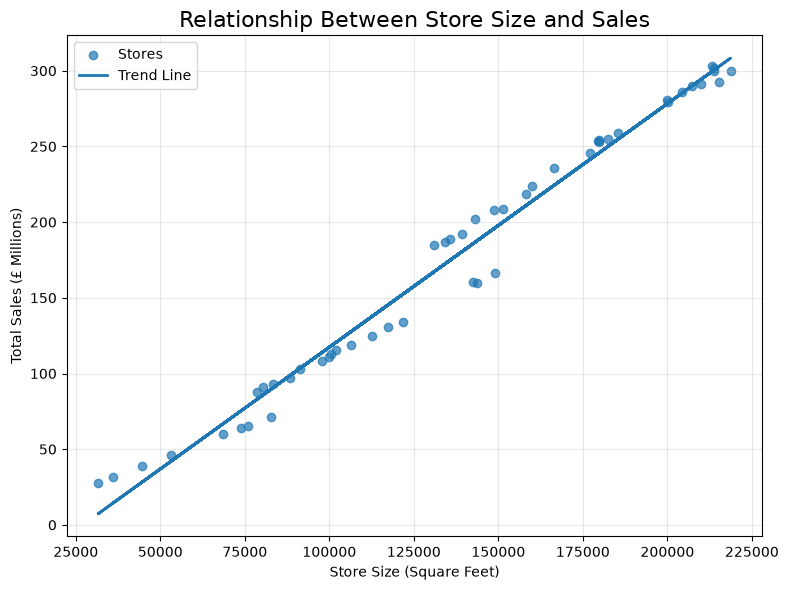

In [46]:
# =====================================================
# STORE SIZE TREND
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    store_sales["store_size"],
    store_sales["weekly_sales"] / 1_000_000,
    alpha=0.7,
    label="Stores"
)

z = np.polyfit(
    store_sales["store_size"],
    store_sales["weekly_sales"] / 1_000_000,
    1
)

p = np.poly1d(z)

plt.plot(
    store_sales["store_size"],
    p(store_sales["store_size"]),
    linewidth=2,
    label="Trend Line"
)

plt.title("Relationship Between Store Size and Sales", fontsize=16)

plt.xlabel("Store Size (Square Feet)")

plt.ylabel("Total Sales (£ Millions)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Key Findings

- A very strong positive correlation (0.991) exists between store size and total sales.
- Larger stores consistently generate higher revenue than smaller stores.
- The largest stores are all Type A stores and account for the highest sales figures.
- The smallest stores are predominantly Type C stores and generate the lowest sales.
- Store size appears to be one of the strongest indicators of sales performance within the dataset.

### Business Implications

The analysis suggests that increasing store capacity is associated with higher revenue generation. These findings may support future investment in larger store formats where market demand justifies expansion. However, further analysis would be required to determine whether store size itself causes higher sales or whether other market factors contribute to this relationship.

## 7. Holiday Impact Analysis

### Business Question

How do holiday weeks affect retail sales?

### Business Importance

Retail businesses experience significant fluctuations in customer demand throughout the year. Understanding how holidays influence sales enables management to:

- Improve inventory planning.
- Schedule additional staff during peak periods.
- Allocate marketing budgets effectively.
- Forecast future holiday demand.
- Optimise supply chain operations.

This analysis compares holiday and non-holiday sales and identifies which holidays generate the highest revenue.

In [47]:
# =====================================================
# HOLIDAY WEEK DISTRIBUTION
# =====================================================

print("Holiday Week Distribution")

print(analysis_df["is_holiday"].value_counts())

Holiday Week Distribution
is_holiday
0    138000
1     18000
Name: count, dtype: int64


In [48]:
# =====================================================
# HOLIDAY VS NON-HOLIDAY SALES
# =====================================================

holiday_sales = (
    analysis_df
    .groupby("is_holiday", as_index=False)["weekly_sales"]
    .sum()
)

holiday_sales["Week Type"] = holiday_sales["is_holiday"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

display(holiday_sales)

,is_holiday,weekly_sales,Week Type
0,0,7.293655e+09,Non-Holiday
1,1,1.520889e+09,Holiday


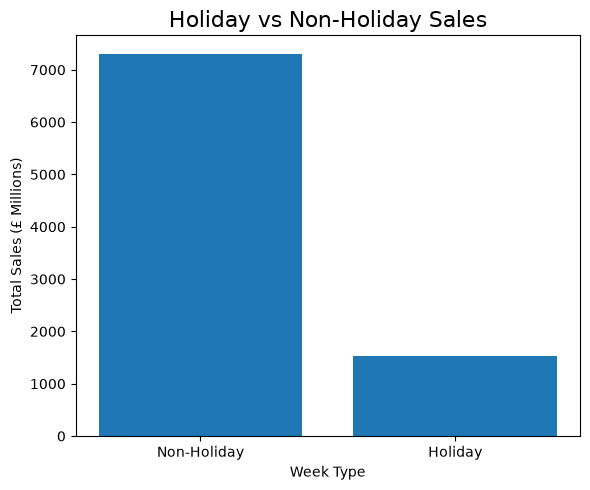

In [49]:
# =====================================================
# BAR CHART
# =====================================================

plt.figure(figsize=(6,5))

plt.bar(
    holiday_sales["Week Type"],
    holiday_sales["weekly_sales"] / 1_000_000
)

plt.title("Holiday vs Non-Holiday Sales", fontsize=16)

plt.xlabel("Week Type")

plt.ylabel("Total Sales (£ Millions)")

plt.tight_layout()

plt.show()

In [50]:
# =====================================================
# AVERAGE WEEKLY SALES
# =====================================================

average_weekly_sales = (
    analysis_df
    .groupby(["date", "is_holiday"])["weekly_sales"]
    .sum()
    .reset_index()
)

average_weekly_sales = (
    average_weekly_sales
    .groupby("is_holiday", as_index=False)["weekly_sales"]
    .mean()
)

average_weekly_sales["Week Type"] = average_weekly_sales["is_holiday"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

display(average_weekly_sales)

,is_holiday,weekly_sales,Week Type
0,0,5.285258e+07,Non-Holiday
1,1,8.449383e+07,Holiday


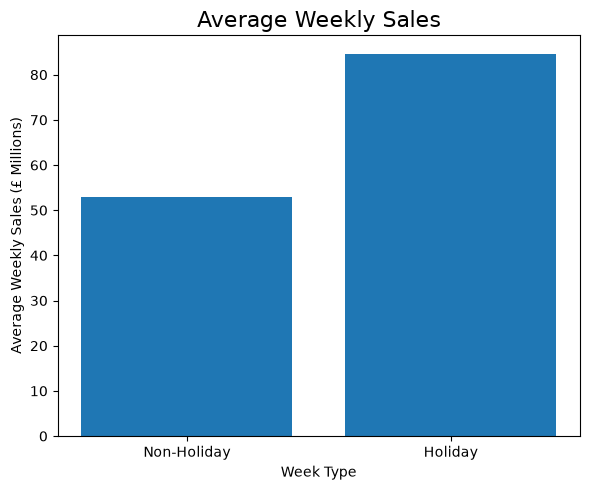

In [51]:
# =====================================================
# AVERAGE SALES CHART
# =====================================================

plt.figure(figsize=(6,5))

plt.bar(
    average_weekly_sales["Week Type"],
    average_weekly_sales["weekly_sales"] / 1_000_000
)

plt.title("Average Weekly Sales", fontsize=16)

plt.xlabel("Week Type")

plt.ylabel("Average Weekly Sales (£ Millions)")

plt.tight_layout()

plt.show()

In [52]:
# =====================================================
# HOLIDAY TYPES
# =====================================================

holiday_names = (
    analysis_df
    .dropna(subset=["holiday_name"])
    [["holiday_name"]]
    .drop_duplicates()
    .sort_values("holiday_name")
)

display(holiday_names)

,holiday_name
940,Black Friday
1020,Christmas
520,Independence Day
700,Labor Day
0,New Year


In [53]:
# =====================================================
# SALES BY HOLIDAY
# =====================================================

holiday_breakdown = (
    analysis_df
    .dropna(subset=["holiday_name"])
    .groupby("holiday_name", as_index=False)["weekly_sales"]
    .sum()
    .sort_values("weekly_sales", ascending=False)
)

display(holiday_breakdown)

,holiday_name,weekly_sales
1,Christmas,4.664632e+08
0,Black Friday,4.319903e+08
3,Labor Day,2.248940e+08
4,New Year,2.124285e+08
2,Independence Day,1.851128e+08


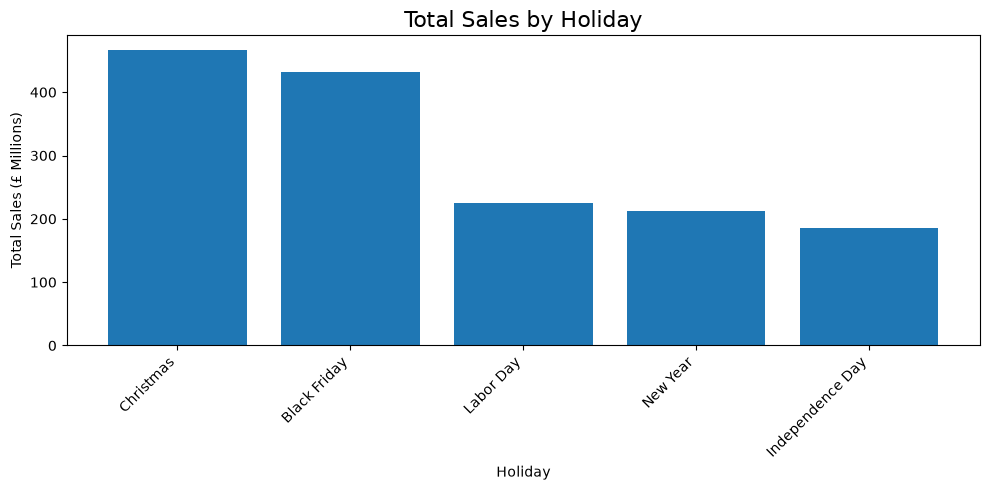

In [54]:
# =====================================================
# HOLIDAY SALES VISUALISATION
# =====================================================

plt.figure(figsize=(10,5))

plt.bar(
    holiday_breakdown["holiday_name"],
    holiday_breakdown["weekly_sales"] / 1_000_000
)

plt.title("Total Sales by Holiday", fontsize=16)

plt.xlabel("Holiday")

plt.ylabel("Total Sales (£ Millions)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [55]:
# =====================================================
# HOLIDAY CONTRIBUTION
# =====================================================

holiday_total = holiday_breakdown["weekly_sales"].sum()

holiday_breakdown["sales_percentage"] = (
    holiday_breakdown["weekly_sales"] /
    holiday_total
) * 100

display(holiday_breakdown)

,holiday_name,weekly_sales,sales_percentage
1,Christmas,4.664632e+08,30.670432
0,Black Friday,4.319903e+08,28.403804
3,Labor Day,2.248940e+08,14.787012
4,New Year,2.124285e+08,13.967394
2,Independence Day,1.851128e+08,12.171357


In [56]:
# =====================================================
# HOLIDAY SALES UPLIFT
# =====================================================

holiday_avg = average_weekly_sales.loc[
    average_weekly_sales["Week Type"] == "Holiday",
    "weekly_sales"
].iloc[0]

non_holiday_avg = average_weekly_sales.loc[
    average_weekly_sales["Week Type"] == "Non-Holiday",
    "weekly_sales"
].iloc[0]

sales_uplift = (
    (holiday_avg - non_holiday_avg) / non_holiday_avg
) * 100

print(f"Holiday Sales Uplift: {sales_uplift:.2f}%")

Holiday Sales Uplift: 59.87%


### Key Findings

- Holiday weeks represent only a small proportion of the dataset but generate substantially higher average weekly sales.
- Average weekly sales during holiday periods (£84.49 million) are approximately 60% higher than during non-holiday periods (£52.85 million).
- Christmas generated the highest total holiday sales, closely followed by Black Friday.
- Christmas and Black Friday together account for almost 60% of all holiday sales.
- Holiday events have a significant influence on retail demand and should be incorporated into forecasting models.

### Business Implications

Holiday periods represent critical revenue-generating opportunities for the business. Effective inventory planning, workforce scheduling and marketing activities should prioritise major retail events, particularly Christmas and Black Friday. Future demand forecasting models should include holiday-related features to improve predictive accuracy.

## 8. External Factors Analysis

### Business Question

How do external economic and environmental factors influence retail sales?

### Business Importance

Retail sales are affected by numerous external variables beyond customer demand. Understanding these relationships enables businesses to:

- Improve demand forecasting.
- Plan inventory more effectively.
- Understand customer purchasing behaviour.
- Support strategic decision-making.
- Identify the strongest drivers of sales.

This analysis investigates the relationship between weekly sales and several external variables, including weather conditions, fuel prices, economic indicators and promotional markdowns.

In [57]:
# =====================================================
# SELECT VARIABLES FOR ANALYSIS
# =====================================================

external_factors = analysis_df[
    [
        "weekly_sales",
        "temperature",
        "fuel_price",
        "cpi",
        "unemployment",
        "markdown_1",
        "markdown_2",
        "markdown_3",
        "markdown_4",
        "markdown_5"
    ]
]

display(external_factors.head())

,weekly_sales,temperature,fuel_price,cpi,unemployment,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5
0,119075.96,97.57,4.83,203.52,3.32,10334.49,5905.86,5261.52,7098.43,876.08
1,119107.85,97.57,4.83,203.52,3.32,10334.49,5905.86,5261.52,7098.43,876.08
2,84369.88,97.57,4.83,203.52,3.32,10334.49,5905.86,5261.52,7098.43,876.08
3,88445.24,97.57,4.83,203.52,3.32,10334.49,5905.86,5261.52,7098.43,876.08
4,65159.85,97.57,4.83,203.52,3.32,10334.49,5905.86,5261.52,7098.43,876.08


In [58]:
# =====================================================
# CORRELATION MATRIX
# =====================================================

correlation_matrix = external_factors.corr()

display(correlation_matrix)

,weekly_sales,temperature,fuel_price,cpi,unemployment,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5
weekly_sales,1.000000,-0.001684,-0.002101,-0.001532,-0.006974,0.106318,0.105280,0.093338,0.100456,0.100337
temperature,-0.001684,1.000000,-0.014806,-0.010541,0.006568,-0.005981,0.010321,-0.009872,-0.017186,0.014383
fuel_price,-0.002101,-0.014806,1.000000,0.000127,0.008172,0.011201,-0.004417,-0.017315,0.000818,-0.004186
cpi,-0.001532,-0.010541,0.000127,1.000000,-0.012041,0.005749,0.002165,-0.034261,0.007183,0.007081
unemployment,-0.006974,0.006568,0.008172,-0.012041,1.000000,-0.008494,0.004871,0.010258,0.011346,-0.000854
markdown_1,0.106318,-0.005981,0.011201,0.005749,-0.008494,1.000000,0.244197,0.233141,0.208820,0.210051
markdown_2,0.105280,0.010321,-0.004417,0.002165,0.004871,0.244197,1.000000,0.228401,0.240810,0.212390
markdown_3,0.093338,-0.009872,-0.017315,-0.034261,0.010258,0.233141,0.228401,1.000000,0.210850,0.236578
markdown_4,0.100456,-0.017186,0.000818,0.007183,0.011346,0.208820,0.240810,0.210850,1.000000,0.219329
markdown_5,0.100337,0.014383,-0.004186,0.007081,-0.000854,0.210051,0.212390,0.236578,0.219329,1.000000


In [59]:
# =====================================================
# CORRELATION WITH SALES
# =====================================================

sales_correlation = (
    correlation_matrix["weekly_sales"]
    .sort_values(ascending=False)
)

display(sales_correlation)

weekly_sales    1.000000
markdown_1      0.106318
markdown_2      0.105280
markdown_4      0.100456
markdown_5      0.100337
markdown_3      0.093338
cpi            -0.001532
temperature    -0.001684
fuel_price     -0.002101
unemployment   -0.006974
Name: weekly_sales, dtype: float64

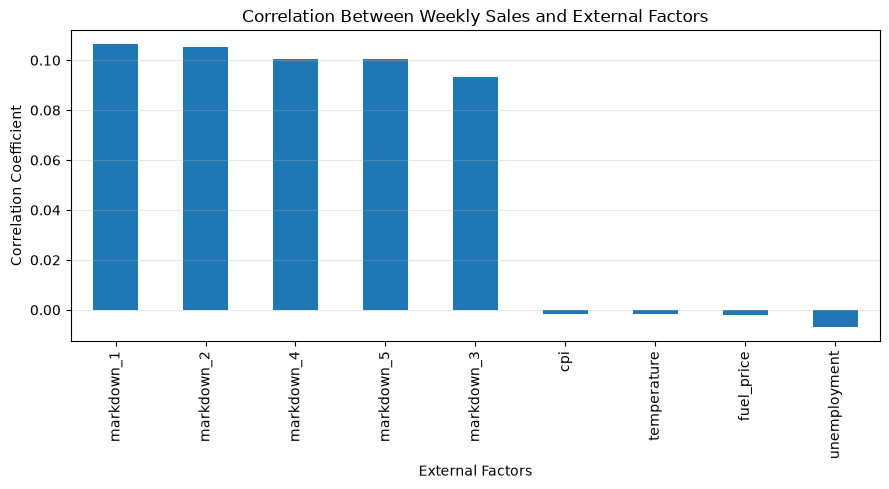

In [60]:
# =====================================================
# CORRELATION BAR CHART
# =====================================================

plt.figure(figsize=(9,5))

sales_correlation.drop("weekly_sales").plot(kind="bar")

plt.title("Correlation Between Weekly Sales and External Factors")

plt.ylabel("Correlation Coefficient")

plt.xlabel("External Factors")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [61]:
# =====================================================
# STRONGEST EXTERNAL FACTOR
# =====================================================

strongest_factor = (
    sales_correlation
    .drop("weekly_sales")
    .abs()
    .idxmax()
)

print(f"Strongest external factor: {strongest_factor}")

Strongest external factor: markdown_1


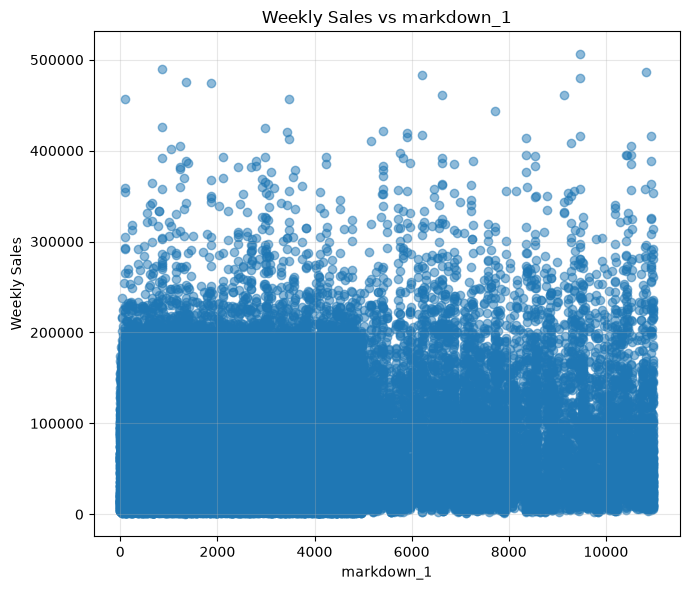

In [62]:
# =====================================================
# SCATTER PLOT
# =====================================================

plt.figure(figsize=(7,6))

plt.scatter(
    analysis_df[strongest_factor],
    analysis_df["weekly_sales"],
    alpha=0.5
)

plt.title(f"Weekly Sales vs {strongest_factor}")

plt.xlabel(strongest_factor)

plt.ylabel("Weekly Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [63]:
# =====================================================
# SUMMARY STATISTICS
# =====================================================

display(external_factors.describe())

,weekly_sales,temperature,fuel_price,cpi,unemployment,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5
count,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000,156000.000000
mean,56503.488802,59.875755,3.986344,240.469559,6.485572,2831.840176,1708.091033,2295.922200,1982.042679,2561.790629
std,46717.490663,23.114765,0.864025,34.600848,2.014998,1977.833293,1187.621364,1579.278801,1351.446660,1769.691198
min,819.660000,20.020000,2.500000,180.000000,3.000000,0.180000,0.200000,1.010000,1.130000,0.140000
25%,21255.962500,39.942500,3.240000,211.027500,4.720000,1308.727500,787.155000,1095.917500,969.917500,1198.375000
50%,43394.870000,60.065000,3.970000,240.945000,6.490000,2652.495000,1612.570000,2174.595000,1862.980000,2417.900000
75%,79604.107500,79.910000,4.750000,270.445000,8.220000,4027.545000,2423.002500,3212.695000,2790.137500,3600.245000
max,505958.730000,99.970000,5.500000,299.990000,10.000000,10977.070000,6599.720000,8798.150000,7692.880000,9891.190000


## Key Findings

- Promotional markdowns exhibit the strongest positive relationship with weekly sales, although the correlations are relatively weak (approximately 0.10).
- Temperature, fuel price, CPI and unemployment show almost no linear relationship with weekly sales.
- Retail sales are influenced by multiple interacting factors rather than a single external variable.
- Promotional activity appears to contribute to increased sales but is not the sole driver of customer demand.
- Machine learning models that combine multiple variables are expected to outperform simple correlation-based analysis.

# Feature Engineering

## Objective

Feature engineering transforms existing variables into new features that improve business analysis, dashboard development and predictive modelling.

The features created in this section will support:

- SQL reporting
- Power BI dashboards
- Machine Learning models
- Forecasting
- KPI calculations
- Time-series analysis

In [64]:
# =====================================================
# FEATURE ENGINEERING - DATE FEATURES
# =====================================================

# Creating new features from the date column

analysis_df["year"] = analysis_df["date"].dt.year

analysis_df["month"] = analysis_df["date"].dt.month

analysis_df["month_name"] = analysis_df["date"].dt.month_name()

analysis_df["quarter"] = analysis_df["date"].dt.quarter

analysis_df["week_number"] = analysis_df["date"].dt.isocalendar().week.astype(int)

analysis_df["day_of_week"] = analysis_df["date"].dt.dayofweek

analysis_df["day_name"] = analysis_df["date"].dt.day_name()

print("Date features created successfully.")

Date features created successfully.


In [65]:
# =====================================================
# VERIFY NEW FEATURES
# =====================================================

new_date_features = [
    "date",
    "year",
    "month",
    "month_name",
    "quarter",
    "week_number",
    "day_of_week",
    "day_name"
]

display(analysis_df[new_date_features].head(10))

,date,year,month,month_name,quarter,week_number,day_of_week,day_name
0,2022-01-01,2022,1,January,1,52,5,Saturday
1,2022-01-01,2022,1,January,1,52,5,Saturday
2,2022-01-01,2022,1,January,1,52,5,Saturday
3,2022-01-01,2022,1,January,1,52,5,Saturday
4,2022-01-01,2022,1,January,1,52,5,Saturday
5,2022-01-01,2022,1,January,1,52,5,Saturday
6,2022-01-01,2022,1,January,1,52,5,Saturday
7,2022-01-01,2022,1,January,1,52,5,Saturday
8,2022-01-01,2022,1,January,1,52,5,Saturday
9,2022-01-01,2022,1,January,1,52,5,Saturday


In [66]:
# =====================================================
# CHECK DATA TYPES
# =====================================================

analysis_df[
    [
        "year",
        "month",
        "quarter",
        "week_number",
        "day_of_week"
    ]
].info()

<class 'pandas.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   year         156000 non-null  int32
 1   month        156000 non-null  int32
 2   quarter      156000 non-null  int32
 3   week_number  156000 non-null  int64
 4   day_of_week  156000 non-null  int32
dtypes: int32(4), int64(1)
memory usage: 3.6 MB


In [67]:
# =====================================================
# DATE FEATURE SUMMARY
# =====================================================

print("Years:", sorted(analysis_df["year"].unique()))

print("\nMonths:", sorted(analysis_df["month"].unique()))

print("\nQuarters:", sorted(analysis_df["quarter"].unique()))

print("\nDay Names:")

print(analysis_df["day_name"].unique())

Years: [np.int32(2022), np.int32(2023), np.int32(2024)]

Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Quarters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]

Day Names:
<StringArray>
['Saturday']
Length: 1, dtype: str


In [68]:
# =====================================================
# REMOVE NON-INFORMATIVE FEATURES
# =====================================================

analysis_df.drop(
    columns=["day_of_week", "day_name"],
    inplace=True
)

print("Removed day_of_week and day_name (constant features).")

Removed day_of_week and day_name (constant features).


In [69]:
analysis_df.columns.tolist()

['store_id',
 'department',
 'date',
 'weekly_sales',
 'is_holiday',
 'temperature',
 'fuel_price',
 'markdown_1',
 'markdown_2',
 'markdown_3',
 'markdown_4',
 'markdown_5',
 'cpi',
 'unemployment',
 'holiday_name',
 'season',
 'store_type',
 'store_size',
 'region',
 'year',
 'month',
 'month_name',
 'quarter',
 'week_number']

In [70]:
print("Years:", sorted(int(y) for y in analysis_df["year"].unique()))

print("Months:", sorted(int(m) for m in analysis_df["month"].unique()))

print("Quarters:", sorted(int(q) for q in analysis_df["quarter"].unique()))

Years: [2022, 2023, 2024]
Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Quarters: [1, 2, 3, 4]


## Calendar Features

### Objective

Calendar features capture important business reporting periods and events that cannot be represented by the date alone.

These features improve:

- Business reporting
- Quarterly analysis
- Forecasting
- Dashboard filtering
- Machine learning models

In [71]:
# =====================================================
# CREATE A STANDARD HOLIDAY FLAG
# =====================================================

analysis_df["holiday_flag"] = analysis_df["is_holiday"]

print("Holiday flag created successfully.")

Holiday flag created successfully.


In [72]:
# =====================================================
# MONTH-END FLAG
# =====================================================

analysis_df["month_end"] = analysis_df["date"].dt.is_month_end

print("Month-end flag created successfully.")

Month-end flag created successfully.


In [73]:
# =====================================================
# QUARTER-END FLAG
# =====================================================

analysis_df["quarter_end"] = analysis_df["date"].dt.is_quarter_end

print("Quarter-end flag created successfully.")

Quarter-end flag created successfully.


In [74]:
# =====================================================
# VERIFY CALENDAR FEATURES
# =====================================================

display(
    analysis_df[
        [
            "date",
            "holiday_flag",
            "month_end",
            "quarter_end"
        ]
    ].head(15)
)

,date,holiday_flag,month_end,quarter_end
0,2022-01-01,1,False,False
1,2022-01-01,1,False,False
2,2022-01-01,1,False,False
3,2022-01-01,1,False,False
4,2022-01-01,1,False,False
5,2022-01-01,1,False,False
6,2022-01-01,1,False,False
7,2022-01-01,1,False,False
8,2022-01-01,1,False,False
9,2022-01-01,1,False,False


In [75]:
# =====================================================
# FEATURE DISTRIBUTION
# =====================================================

print("Holiday Flag")
print(analysis_df["holiday_flag"].value_counts())

print("\nMonth End")
print(analysis_df["month_end"].value_counts())

print("\nQuarter End")
print(analysis_df["quarter_end"].value_counts())

Holiday Flag
holiday_flag
0    138000
1     18000
Name: count, dtype: int64

Month End
month_end
False    151000
True       5000
Name: count, dtype: int64

Quarter End
quarter_end
False    154000
True       2000
Name: count, dtype: int64


In [76]:
# =====================================================
# REMOVE LOW-INFORMATION CALENDAR FEATURES
# =====================================================

analysis_df.drop(
    columns=["month_end", "quarter_end"],
    inplace=True
)

print("Removed month_end and quarter_end.")

Removed month_end and quarter_end.


## Sales Features

### Objective

Sales features capture historical sales behaviour and trends.

These engineered variables are commonly used in:

- Time-series forecasting
- Machine learning models
- KPI reporting
- Demand planning
- Trend analysis

Historical sales patterns often provide stronger predictive power than external variables alone.

In [77]:
# =====================================================
# SORT DATA FOR TIME-SERIES FEATURES
# =====================================================

analysis_df = analysis_df.sort_values(
    by=["store_id", "department", "date"]
).reset_index(drop=True)

print("Dataset sorted successfully.")

Dataset sorted successfully.


### Previous Week Sales

A lag feature records the previous week's sales for each Store–Department combination.

Lag features are among the most important predictors in retail demand forecasting because sales often depend on recent historical performance.

In [78]:
# =====================================================
# PREVIOUS WEEK SALES (LAG 1)
# =====================================================

analysis_df["previous_week_sales"] = (
    analysis_df
    .groupby(["store_id", "department"])["weekly_sales"]
    .shift(1)
)

print("Previous week sales feature created.")

Previous week sales feature created.


In [79]:
# =====================================================
# VERIFY PREVIOUS WEEK SALES
# =====================================================

display(
    analysis_df[
        [
            "store_id",
            "department",
            "date",
            "weekly_sales",
            "previous_week_sales"
        ]
    ].head(15)
)

,store_id,department,date,weekly_sales,previous_week_sales
0,1,1,2022-01-01,119075.96,NaN
1,1,1,2022-01-08,35525.05,119075.96
2,1,1,2022-01-15,14847.56,35525.05
3,1,1,2022-01-22,45254.57,14847.56
4,1,1,2022-01-29,15166.69,45254.57
5,1,1,2022-02-05,15601.13,15166.69
6,1,1,2022-02-12,52743.22,15601.13
7,1,1,2022-02-19,38995.95,52743.22
8,1,1,2022-02-26,62899.98,38995.95
9,1,1,2022-03-05,56896.47,62899.98


In [80]:
# =====================================================
# CHECK LAG FEATURE
# =====================================================

missing_previous = analysis_df["previous_week_sales"].isna().sum()

print(f"Missing Previous Week Sales: {missing_previous:,}")

Missing Previous Week Sales: 1,000


In [81]:
# =====================================================
# FOUR-WEEK ROLLING AVERAGE
# =====================================================

analysis_df["rolling_4_week_avg"] = (
    analysis_df
    .groupby(["store_id", "department"])["weekly_sales"]
    .transform(
        lambda sales: sales.rolling(window=4, min_periods=1).mean()
    )
)

print("Four-week rolling average created.")

Four-week rolling average created.


In [82]:
# =====================================================
# VERIFY ROLLING AVERAGE
# =====================================================

display(
    analysis_df[
        [
            "store_id",
            "department",
            "date",
            "weekly_sales",
            "rolling_4_week_avg"
        ]
    ].head(15)
)

,store_id,department,date,weekly_sales,rolling_4_week_avg
0,1,1,2022-01-01,119075.96,119075.960000
1,1,1,2022-01-08,35525.05,77300.505000
2,1,1,2022-01-15,14847.56,56482.856667
3,1,1,2022-01-22,45254.57,53675.785000
4,1,1,2022-01-29,15166.69,27698.467500
5,1,1,2022-02-05,15601.13,22717.487500
6,1,1,2022-02-12,52743.22,32191.402500
7,1,1,2022-02-19,38995.95,30626.747500
8,1,1,2022-02-26,62899.98,42560.070000
9,1,1,2022-03-05,56896.47,52883.905000


### Weekly Sales Growth

Weekly Sales Growth measures the percentage increase or decrease in sales compared to the previous week.

This KPI is widely used to:

- Monitor business performance
- Detect rapid growth or decline
- Identify unusual sales patterns
- Support forecasting and trend analysis

In [83]:
# =====================================================
# WEEKLY SALES GROWTH (%)
# =====================================================

analysis_df["weekly_sales_growth_pct"] = (
    (
        analysis_df["weekly_sales"]
        - analysis_df["previous_week_sales"]
    )
    / analysis_df["previous_week_sales"]
) * 100

print("Weekly sales growth feature created.")

Weekly sales growth feature created.


In [84]:
# =====================================================
# VERIFY WEEKLY SALES GROWTH
# =====================================================

display(
    analysis_df[
        [
            "store_id",
            "department",
            "date",
            "weekly_sales",
            "previous_week_sales",
            "weekly_sales_growth_pct"
        ]
    ].head(15)
)

,store_id,department,date,weekly_sales,previous_week_sales,weekly_sales_growth_pct
0,1,1,2022-01-01,119075.96,NaN,NaN
1,1,1,2022-01-08,35525.05,119075.96,-70.166060
2,1,1,2022-01-15,14847.56,35525.05,-58.205379
3,1,1,2022-01-22,45254.57,14847.56,204.794660
4,1,1,2022-01-29,15166.69,45254.57,-66.485838
5,1,1,2022-02-05,15601.13,15166.69,2.864435
6,1,1,2022-02-12,52743.22,15601.13,238.073075
7,1,1,2022-02-19,38995.95,52743.22,-26.064525
8,1,1,2022-02-26,62899.98,38995.95,61.298750
9,1,1,2022-03-05,56896.47,62899.98,-9.544534


### Cumulative Sales

Cumulative Sales represent the running total of weekly sales for each Store–Department combination.

Unlike weekly sales, cumulative sales show long-term performance over time and help visualise business growth.

In [85]:
# =====================================================
# CUMULATIVE SALES
# =====================================================

analysis_df["cumulative_sales"] = (
    analysis_df
    .groupby(["store_id", "department"])["weekly_sales"]
    .cumsum()
)

print("Cumulative sales feature created.")

Cumulative sales feature created.


In [86]:
# =====================================================
# VERIFY CUMULATIVE SALES
# =====================================================

display(
    analysis_df[
        [
            "store_id",
            "department",
            "date",
            "weekly_sales",
            "cumulative_sales"
        ]
    ].head(15)
)

,store_id,department,date,weekly_sales,cumulative_sales
0,1,1,2022-01-01,119075.96,119075.96
1,1,1,2022-01-08,35525.05,154601.01
2,1,1,2022-01-15,14847.56,169448.57
3,1,1,2022-01-22,45254.57,214703.14
4,1,1,2022-01-29,15166.69,229869.83
5,1,1,2022-02-05,15601.13,245470.96
6,1,1,2022-02-12,52743.22,298214.18
7,1,1,2022-02-19,38995.95,337210.13
8,1,1,2022-02-26,62899.98,400110.11
9,1,1,2022-03-05,56896.47,457006.58


### Four-Week Rolling Standard Deviation

The Four-Week Rolling Standard Deviation measures the variability of weekly sales over the previous four weeks for each Store–Department combination.

Unlike the rolling average, which captures the overall sales trend, the rolling standard deviation measures how consistent or volatile sales have been.

This feature is useful for:

- Identifying products or departments with unstable demand.
- Measuring sales volatility.
- Supporting inventory and supply chain planning.
- Improving forecasting models by capturing demand uncertainty.

In [87]:
# =====================================================
# FOUR-WEEK ROLLING STANDARD DEVIATION
# =====================================================

analysis_df["rolling_4_week_std"] = (
    analysis_df
    .groupby(["store_id", "department"])["weekly_sales"]
    .transform(
        lambda sales: sales.rolling(window=4, min_periods=2).std()
    )
)

print("Four-week rolling standard deviation created.")

Four-week rolling standard deviation created.


In [88]:
# =====================================================
# VERIFY ROLLING STANDARD DEVIATION
# =====================================================

display(
    analysis_df[
        [
            "store_id",
            "department",
            "date",
            "weekly_sales",
            "rolling_4_week_std"
        ]
    ].head(15)
)

,store_id,department,date,weekly_sales,rolling_4_week_std
0,1,1,2022-01-01,119075.96,NaN
1,1,1,2022-01-08,35525.05,59079.415035
2,1,1,2022-01-15,14847.56,55184.346393
3,1,1,2022-01-22,45254.57,45406.240356
4,1,1,2022-01-29,15166.69,15184.020103
5,1,1,2022-02-05,15601.13,15027.895544
6,1,1,2022-02-12,52743.22,19647.743933
7,1,1,2022-02-19,38995.95,18474.888051
8,1,1,2022-02-26,62899.98,20468.641707
9,1,1,2022-03-05,56896.47,10154.104632


In [89]:
# =====================================================
# CHECK MISSING VALUES
# =====================================================

missing_std = analysis_df["rolling_4_week_std"].isna().sum()

print(f"Missing Rolling Standard Deviation: {missing_std:,}")

Missing Rolling Standard Deviation: 1,000


## Categorical Feature Preparation

Machine learning algorithms require numerical input.

This section identifies the remaining categorical variables in the dataset before converting them into numerical representations suitable for modelling.

The objective is to prepare the dataset for predictive modelling while preserving the business meaning of each variable.

In [90]:
# =====================================================
# IDENTIFY CATEGORICAL VARIABLES
# =====================================================

categorical_columns = analysis_df.select_dtypes(
    include=["str", "category"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
['holiday_name', 'season', 'store_type', 'region', 'month_name']


## Feature Selection

Before building predictive models, the dataset should be reviewed to identify features that are useful for modelling.

Some columns may contain duplicate information, constant values or descriptive labels intended only for reporting and visualisation.

The objective of this section is to create a clean modelling dataset by retaining informative variables and removing redundant features.

In [91]:
# =====================================================
# REVIEW ALL FEATURES
# =====================================================

print(f"Total Columns: {len(analysis_df.columns)}")

analysis_df.columns.tolist()

Total Columns: 30


['store_id',
 'department',
 'date',
 'weekly_sales',
 'is_holiday',
 'temperature',
 'fuel_price',
 'markdown_1',
 'markdown_2',
 'markdown_3',
 'markdown_4',
 'markdown_5',
 'cpi',
 'unemployment',
 'holiday_name',
 'season',
 'store_type',
 'store_size',
 'region',
 'year',
 'month',
 'month_name',
 'quarter',
 'week_number',
 'holiday_flag',
 'previous_week_sales',
 'rolling_4_week_avg',
 'weekly_sales_growth_pct',
 'cumulative_sales',
 'rolling_4_week_std']

In [92]:
# =====================================================
# REVIEW DATA TYPES
# =====================================================

analysis_df.dtypes

store_id                            int64
department                          int64
date                       datetime64[us]
weekly_sales                      float64
is_holiday                          int64
temperature                       float64
fuel_price                        float64
markdown_1                        float64
markdown_2                        float64
markdown_3                        float64
markdown_4                        float64
markdown_5                        float64
cpi                               float64
unemployment                      float64
holiday_name                          str
season                                str
store_type                            str
store_size                          int64
region                                str
year                                int32
month                               int32
month_name                            str
quarter                             int32
week_number                       

In [93]:
# =====================================================
# REVIEW CATEGORICAL FEATURES
# =====================================================

categorical_columns = analysis_df.select_dtypes(
    include=["string", "category"]
).columns

for column in categorical_columns:

    print("=" * 50)
    print(column)

    print(analysis_df[column].value_counts(dropna=False))

holiday_name
holiday_name
NaN                 138000
Christmas             5000
Black Friday          4000
New Year              3000
Independence Day      3000
Labor Day             3000
Name: count, dtype: int64
season
season
Summer    40000
Spring    39000
Fall      39000
Winter    38000
Name: count, dtype: int64
store_type
store_type
A    81120
B    49920
C    24960
Name: count, dtype: int64
region
region
East     49920
North    40560
South    37440
West     28080
Name: count, dtype: int64
month_name
month_name
April        14000
July         14000
January      13000
March        13000
June         13000
August       13000
September    13000
October      13000
November     13000
December     13000
February     12000
May          12000
Name: count, dtype: int64


### Removing Redundant Features

Some variables contain duplicate or low-value information that is already represented by other features.

Removing redundant variables simplifies the modelling dataset, reduces unnecessary complexity and avoids introducing duplicated information into machine learning models.

In [94]:
# =====================================================
# REMOVE REDUNDANT FEATURES
# =====================================================

columns_to_remove = [
    "holiday_name",
    "month_name",
    "holiday_flag"
]

analysis_df.drop(
    columns=columns_to_remove,
    inplace=True
)

print("Removed redundant columns:")
print(columns_to_remove)

Removed redundant columns:
['holiday_name', 'month_name', 'holiday_flag']


In [95]:
# =====================================================
# VERIFY REMAINING COLUMNS
# =====================================================

print(f"Total Columns: {len(analysis_df.columns)}")

analysis_df.columns.tolist()

Total Columns: 27


['store_id',
 'department',
 'date',
 'weekly_sales',
 'is_holiday',
 'temperature',
 'fuel_price',
 'markdown_1',
 'markdown_2',
 'markdown_3',
 'markdown_4',
 'markdown_5',
 'cpi',
 'unemployment',
 'season',
 'store_type',
 'store_size',
 'region',
 'year',
 'month',
 'quarter',
 'week_number',
 'previous_week_sales',
 'rolling_4_week_avg',
 'weekly_sales_growth_pct',
 'cumulative_sales',
 'rolling_4_week_std']

### Encoding Categorical Variables

Machine learning algorithms require numerical input.

The remaining categorical variables are converted into numerical features using One-Hot Encoding.

One-Hot Encoding creates a binary indicator column for each category while avoiding any artificial ordering between categories.

In [96]:
# =====================================================
# ONE-HOT ENCODE CATEGORICAL FEATURES
# =====================================================

analysis_df = pd.get_dummies(
    analysis_df,
    columns=[
        "season",
        "store_type",
        "region"
    ],
    drop_first=True,
    dtype=int
)

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [97]:
# =====================================================
# VERIFY ENCODED DATASET
# =====================================================

print(f"Dataset Shape: {analysis_df.shape}")

analysis_df.head()

Dataset Shape: (156000, 32)


,store_id,department,date,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,store_size,year,month,quarter,week_number,previous_week_sales,rolling_4_week_avg,weekly_sales_growth_pct,cumulative_sales,rolling_4_week_std,season_Spring,season_Summer,season_Winter,store_type_B,store_type_C,region_North,region_South,region_West
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,213810,2022,1,1,52,NaN,119075.960000,NaN,119075.96,NaN,0,0,1,0,0,1,0,0
1,1,1,2022-01-08,35525.05,0,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,213810,2022,1,1,1,119075.96,77300.505000,-70.166060,154601.01,59079.415035,0,0,1,0,0,1,0,0
2,1,1,2022-01-15,14847.56,0,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,213810,2022,1,1,2,35525.05,56482.856667,-58.205379,169448.57,55184.346393,0,0,1,0,0,1,0,0
3,1,1,2022-01-22,45254.57,0,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,213810,2022,1,1,3,14847.56,53675.785000,204.794660,214703.14,45406.240356,0,0,1,0,0,1,0,0
4,1,1,2022-01-29,15166.69,0,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,213810,2022,1,1,4,45254.57,27698.467500,-66.485838,229869.83,15184.020103,0,0,1,0,0,1,0,0


## Missing Value Assessment

Some engineered features naturally contain missing values because they depend on historical observations.

These missing values are expected and result from the first observation within each Store–Department time series rather than incomplete data collection.

This section verifies the extent of missing values before preparing the final modelling dataset.

In [98]:
# =====================================================
# CHECK MISSING VALUES
# =====================================================

missing_values = (
    analysis_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

weekly_sales_growth_pct    1000
rolling_4_week_std         1000
previous_week_sales        1000
dtype: int64

### Removing Initial Observations

The first observation for each Store–Department combination does not have historical sales information.

Since lag-based features cannot be calculated for these observations, they are removed from the modelling dataset.

This ensures that every remaining observation contains complete historical information.

In [99]:
# =====================================================
# REMOVE ROWS WITH ENGINEERED NaN VALUES
# =====================================================

model_df = analysis_df.dropna().reset_index(drop=True)

print("Original Dataset Shape :", analysis_df.shape)
print("Model Dataset Shape    :", model_df.shape)

Original Dataset Shape : (156000, 32)
Model Dataset Shape    : (155000, 32)


In [100]:
# =====================================================
# VERIFY MODEL DATASET
# =====================================================

model_df.isnull().sum()

store_id                   0
department                 0
date                       0
weekly_sales               0
is_holiday                 0
temperature                0
fuel_price                 0
markdown_1                 0
markdown_2                 0
markdown_3                 0
markdown_4                 0
markdown_5                 0
cpi                        0
unemployment               0
store_size                 0
year                       0
month                      0
quarter                    0
week_number                0
previous_week_sales        0
rolling_4_week_avg         0
weekly_sales_growth_pct    0
cumulative_sales           0
rolling_4_week_std         0
season_Spring              0
season_Summer              0
season_Winter              0
store_type_B               0
store_type_C               0
region_North               0
region_South               0
region_West                0
dtype: int64

### Final Modelling Dataset

After feature engineering and preprocessing, the dataset contains complete observations ready for machine learning.

The dataset includes historical sales behaviour, calendar information, external economic indicators and store characteristics.

In [101]:
# =====================================================
# MODEL DATASET OVERVIEW
# =====================================================

print("Model Dataset Shape:")
print(model_df.shape)

print("\nNumber of Features:")
print(model_df.shape[1])

print("\nData Types:")
display(model_df.dtypes)

Model Dataset Shape:
(155000, 32)

Number of Features:
32

Data Types:


store_id                            int64
department                          int64
date                       datetime64[us]
weekly_sales                      float64
is_holiday                          int64
temperature                       float64
fuel_price                        float64
markdown_1                        float64
markdown_2                        float64
markdown_3                        float64
markdown_4                        float64
markdown_5                        float64
cpi                               float64
unemployment                      float64
store_size                          int64
year                                int32
month                               int32
quarter                             int32
week_number                         int64
previous_week_sales               float64
rolling_4_week_avg                float64
weekly_sales_growth_pct           float64
cumulative_sales                  float64
rolling_4_week_std                

### Saving the Processed Dataset

The processed modelling dataset is saved for reuse in future modelling and evaluation stages.

Saving intermediate datasets improves reproducibility and avoids repeating preprocessing steps.

In [102]:
# =====================================================
# SAVE PROCESSED DATASET
# =====================================================

model_df.to_csv(
    "../data/processed/model_dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [103]:
# =====================================================
# VERIFY SAVED DATASET
# =====================================================

pd.read_csv(
    "../data/processed/model_dataset.csv"
).head()

,store_id,department,date,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,store_size,year,month,quarter,week_number,previous_week_sales,rolling_4_week_avg,weekly_sales_growth_pct,cumulative_sales,rolling_4_week_std,season_Spring,season_Summer,season_Winter,store_type_B,store_type_C,region_North,region_South,region_West
0,1,1,2022-01-08,35525.05,0,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,213810,2022,1,1,1,119075.96,77300.505000,-70.166060,154601.01,59079.415035,0,0,1,0,0,1,0,0
1,1,1,2022-01-15,14847.56,0,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,213810,2022,1,1,2,35525.05,56482.856667,-58.205379,169448.57,55184.346393,0,0,1,0,0,1,0,0
2,1,1,2022-01-22,45254.57,0,25.92,3.58,579.35,2589.31,2493.19,1158.14,286.01,217.32,5.28,213810,2022,1,1,3,14847.56,53675.785000,204.794660,214703.14,45406.240356,0,0,1,0,0,1,0,0
3,1,1,2022-01-29,15166.69,0,78.37,4.41,4436.06,1416.64,478.38,2496.36,3423.53,247.35,8.40,213810,2022,1,1,4,45254.57,27698.467500,-66.485838,229869.83,15184.020103,0,0,1,0,0,1,0,0
4,1,1,2022-02-05,15601.13,0,59.50,4.07,2137.71,76.26,431.57,110.00,2863.85,217.72,6.56,213810,2022,2,1,5,15166.69,22717.487500,2.864435,245470.96,15027.895544,0,0,1,0,0,1,0,0
